# Simulate Populations with Spontaneus Birth
## Part 6

in the previous part, we calculated the population using a recursive function. The function is conceptually easy to come up with, but it is inconvenient to use since it requires knowing the value of the previous iteration $P_{t-1}$. In order to calculate the population after $n$ time steps, we need to know the initial population $P_{t=0}$ and then recursively recalculate $P_t$ for $n$ periods.

In this part, we will develop a function $f(t)$ that removes the need for this recursion, allowing us to calculate the exact population $P$ at any time $t$.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### A closer look at $Prob.(T \leq t)$

Remember that in part 5 we found a function $Prob.(T \leq t)$ that allows us to calculate the probabilty of an entity surviving to at least $t$. To calculate the value of $Prob.(T \leq t)$, we simply sum the values of $Prob.(T=t)$ from $t=0$ to $n$. In probability theory, we call $Prob.(T=t)$ a probability density function (PDF), and $Prob.(T \leq t)$ a cumulative distribution function (CDF). Let's calculate and tabulate the values of $Prob.(T \leq t)$ for several time steps.

In [4]:
def survive_exactly(death_chance, t):
    ''' Probability of surviving exactly to time step p given a constant 
        death_chance independent at each step.'''
    if not isinstance(t, int):
        raise TypeError
    else:
        return (1-death_chance)**(t-1)*death_chance if t > 0 else 0


def recursive_pop(n_periods, death_chance, birth_rate, pop):
    ''' Recursive function for popualtion growth with contstant birth rate and
        independent death chance'''

    p_function = [pop] #pop_0 is first item, the function returns
    for t in range(0,n_periods): #pop_t+1 for any t.
        pop = pop*(1-death_chance)+birth_rate
        p_function.append(pop)
    return p_function

In [5]:
# Set simulation parameters
birth_rate = 1
death_chance = 0.1
n_periods = 30

In [13]:
def series_pleqt(n_periods, death_chance):
    """Calculate P(T<=t) for n periods"""
    pleqt_series = pd.Series(
        [
            sum(survive_exactly(death_chance, t)
            for t in range(0,i+1)) #range(0, 0) creates an empty list
            for i in range(0, n_periods+1)
        ],
        name="Prob(T<=t)",
        # index=(f"t={t:02}" for t in range(0, n_periods+1))
        )
    return pleqt_series

# Calculate Prob(T<=t) series
cdf = series_pleqt(n_periods, death_chance)
cdf

0     0.000000
1     0.100000
2     0.190000
3     0.271000
4     0.343900
5     0.409510
6     0.468559
7     0.521703
8     0.569533
9     0.612580
10    0.651322
11    0.686189
12    0.717570
13    0.745813
14    0.771232
15    0.794109
16    0.814698
17    0.833228
18    0.849905
19    0.864915
20    0.878423
21    0.890581
22    0.901523
23    0.911371
24    0.920234
25    0.928210
26    0.935389
27    0.941850
28    0.947665
29    0.952899
30    0.957609
Name: Prob(T<=t), dtype: float64

Let's also visualize the data on a bar chart.

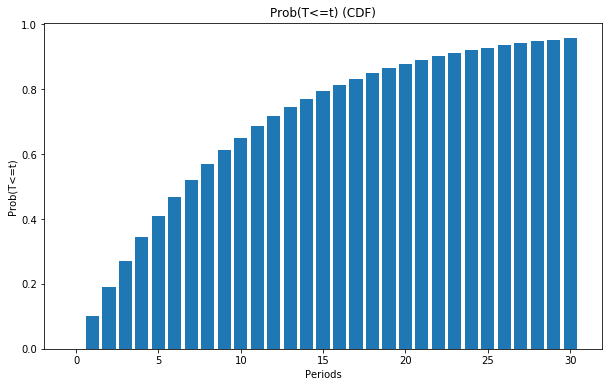

In [15]:
def make_bar(data, title, xlabel, ylabel):
    """ Plot data"""

    fig, ax = plt.subplots(figsize=(10,6))
    ax.bar(data.index, data)
    ax.set(
        title=title,
        xlabel=xlabel,
        ylabel=ylabel,
    )

make_bar(cdf, "Prob(T<=t) (CDF)", "Periods", "Prob(T<=t)")

You can read this bar chart as follows: for any $t$, the height of the bar is the probability that the protocell lived from anywhere between $t=0$ and $t$. So, for example, by looking at $t=4$ we can see that roughly 35% of the time a protocell will survive from anywhere between 0 and and 4 periods. Now, if we multiply this value with the total population, we can determine the expected number of protocells that lived within that timespan. Say we have a population of 100 protocells, we now know that we can expect (on average) ~35 to live anywhere from 0 to 4 periods.

### Calculate Population with $f(t)$

It just so happens that multiplying $Prob.(T \leq t)$ with the population equilibrium ($P=\frac{B}{d}$ from part 3) will give the expected population at $t$ when the starting population $P=0$. The function $f(t)$ is thus:

$$ f(t) =  \frac{Prob.(T \leq t)B}{d} = \frac{(\sum_{t=1}^n (1-d)^{t-1}d)B}{d} $$

Let's try it out:

In [16]:
def population_from_zero(birth_rate, death_chance, t):
    """ Calculate population at t when starting population is 0""" 

    return sum(survive_exactly(death_chance, i) for i in range(0,t+1)) * (birth_rate/death_chance)

def series_population_from_zero(n_periods, birth_rate, death_chance):
    """ Calculate P(T<=t) for n periods"""
    series = pd.Series(
        [
            population_from_zero(birth_rate, death_chance, i)
            for i in range(0, n_periods+1)
        ],
        name="Prob(T<=t)",
        # index=(f"t={t:02}" for t in range(0, n_periods+1))
        )
    return series

# Calculate population series
pop_series = series_population_from_zero(n_periods, birth_rate, death_chance)
pop_series

0     0.000000
1     1.000000
2     1.900000
3     2.710000
4     3.439000
5     4.095100
6     4.685590
7     5.217031
8     5.695328
9     6.125795
10    6.513216
11    6.861894
12    7.175705
13    7.458134
14    7.712321
15    7.941089
16    8.146980
17    8.332282
18    8.499054
19    8.649148
20    8.784233
21    8.905810
22    9.015229
23    9.113706
24    9.202336
25    9.282102
26    9.353892
27    9.418503
28    9.476652
29    9.528987
30    9.576088
Name: Prob(T<=t), dtype: float64

And now let's compare it to the recursive solution from part 6:

In [18]:
# Calculate P_t for n periods
pop_recursive = pd.Series(
    recursive_pop(n_periods, death_chance, birth_rate, 0),
    name="Recursive P_t",
    index=(f"t={t:02}" for t in range(0, n_periods+1))
    )

def series_population_recursive(n_periods, birth_rate, death_chance):
    """ Calculate Population at time step t recursively"""
    series = pd.Series(
        recursive_pop(n_periods, death_chance, birth_rate, 0),
        name="Recursive Pop.",
        # index=(f"t={t:02}" for t in range(0, n_periods+1))
    )
    return series

# Calculate population series
pop_series = series_population_recursive(n_periods, birth_rate, death_chance)
pop_series

0     0.000000
1     1.000000
2     1.900000
3     2.710000
4     3.439000
5     4.095100
6     4.685590
7     5.217031
8     5.695328
9     6.125795
10    6.513216
11    6.861894
12    7.175705
13    7.458134
14    7.712321
15    7.941089
16    8.146980
17    8.332282
18    8.499054
19    8.649148
20    8.784233
21    8.905810
22    9.015229
23    9.113706
24    9.202336
25    9.282102
26    9.353892
27    9.418503
28    9.476652
29    9.528987
30    9.576088
Name: Recursive Pop., dtype: float64

The results match. With $f(t)$ we don't need to know the value of the previous iteration $P_{t-1}$ to calculate the population at period $t$, but this works _only_ when the starting population is 0. Next we will see if we can find the function $f(P_{t=0},\ t)$ so that we can find the population at time step $t$ given _any_ starting population.